 TSLA DATA SPLIT SUMMARY
Total Rows: 2888
Training Set (2015-2024): 2516 rows
Testing Set (2025-2026) : 372 rows


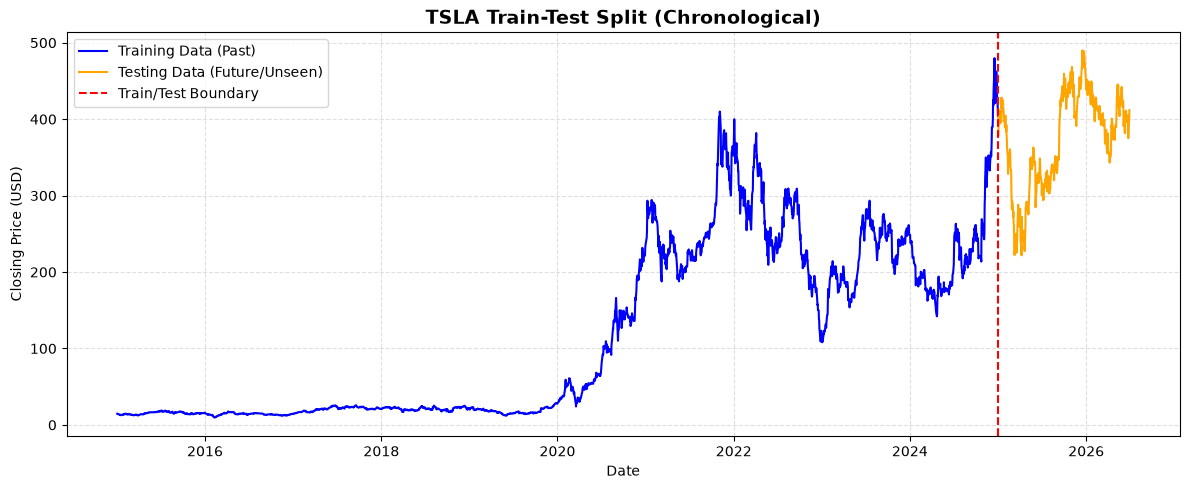

In [3]:
import os
import sys
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
# 1. Define paths 
current_dir = os.getcwd()
project_root = os.path.dirname(current_dir)
processed_dir = os.path.join(project_root, 'data', 'processed')

# Load the cleaned TSLA data
file_path = os.path.join(processed_dir, 'TSLA_cleaned.csv')
tsla_df = pd.read_csv(file_path)

# Ensure 'Date' is a datetime index
tsla_df['Date'] = pd.to_datetime(tsla_df['Date'])
tsla_df.set_index('Date', inplace=True)

# 2. Define the exact cutoff date based on the project configuration
TRAIN_END = '2024-12-31'

# 3. Split the data chronologically
train_data = tsla_df[tsla_df.index <= TRAIN_END]
test_data  = tsla_df[tsla_df.index > TRAIN_END]

print(f"{'='*40}")
print(" TSLA DATA SPLIT SUMMARY")
print(f"{'='*40}")
print(f"Total Rows: {len(tsla_df)}")
print(f"Training Set (2015-2024): {len(train_data)} rows")
print(f"Testing Set (2025-2026) : {len(test_data)} rows")

# 4. Visualize the Split
plt.figure(figsize=(12, 5))
plt.plot(train_data.index, train_data['Close'], label='Training Data (Past)', color='blue')
plt.plot(test_data.index, test_data['Close'], label='Testing Data (Future/Unseen)', color='orange')

plt.title("TSLA Train-Test Split (Chronological)", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.axvline(pd.to_datetime(TRAIN_END), color='red', linestyle='--', label='Train/Test Boundary')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

 TRAINING AUTO-ARIMA MODEL FOR TSLA
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.13 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.29 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.25 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.42 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 1.254 seconds

[BEST MODEL FOUND]
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8183.054
Date:                Mon, 06 Jul 2026   AIC                          16368.109
Time:                        15:49:29   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
               

c:\Users\Hermela\Desktop\10academy\week 9\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Hermela\Desktop\10academy\week 9\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


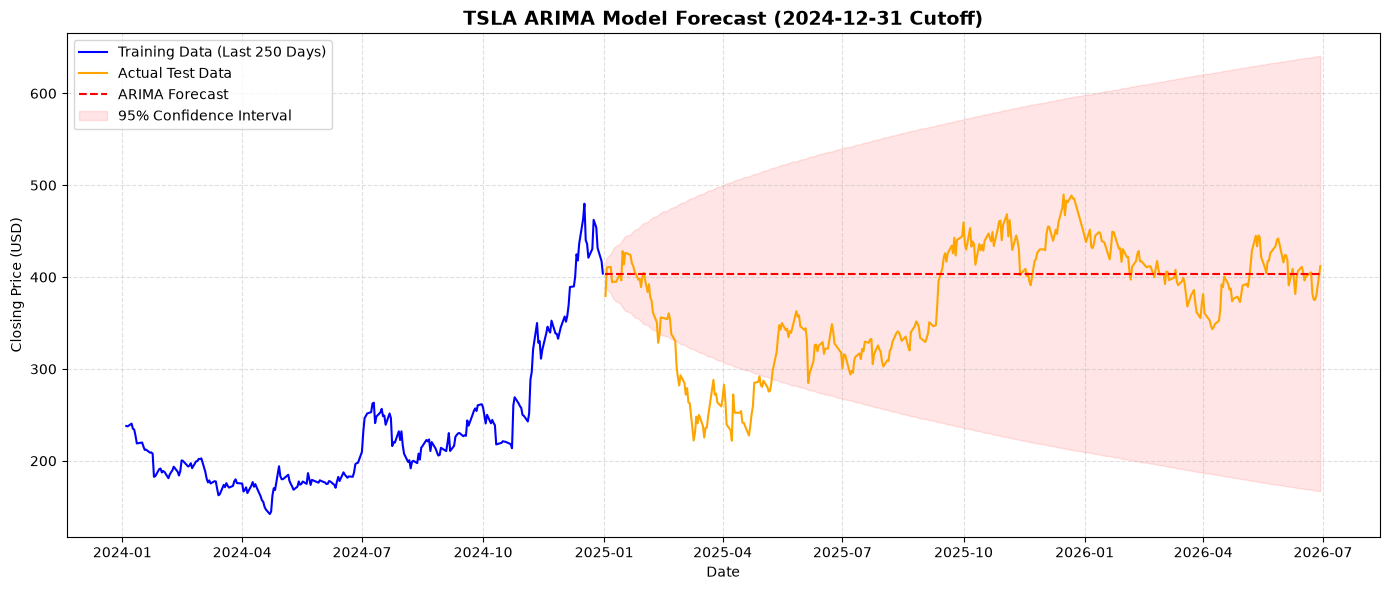

In [4]:
import pmdarima as pm
from sklearn.metrics import mean_absolute_error, mean_squared_error


print(f"{'='*40}")
print(" TRAINING AUTO-ARIMA MODEL FOR TSLA")
print(f"{'='*40}")

# 1. Run auto_arima to find the optimal parameters
# We use the raw 'Close' price because the model handles differencing internally
arima_model = pm.auto_arima(
    train_data['Close'],
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    d=None,           # Let the model automatically determine 'd' based on stationarity
    seasonal=False,   # Stock prices generally don't have strict, repeating seasonality like retail sales
    trace=True,       # Prints out the grid search progress
    error_action='ignore',  
    suppress_warnings=True, 
    stepwise=True     # Uses a smart search algorithm to save time
)

# 2. Print the final selected model
print(f"\n[BEST MODEL FOUND]")
print(arima_model.summary())

# 3. Generate forecasts for the test period
# We forecast exactly the number of days that exist in the test dataset
forecast_steps = len(test_data)
test_predictions, conf_int = arima_model.predict(n_periods=forecast_steps, return_conf_int=True)

# Align the predictions with the test dataset's dates
test_predictions.index = test_data.index
conf_int_df = pd.DataFrame(conf_int, index=test_data.index, columns=['Lower_Bound', 'Upper_Bound'])

# 4. Evaluate Model Performance (Calculate MAE, RMSE, MAPE)
mae = mean_absolute_error(test_data['Close'], test_predictions)
rmse = np.sqrt(mean_squared_error(test_data['Close'], test_predictions))

# MAPE Formula: Mean Absolute Percentage Error
mape = np.mean(np.abs((test_data['Close'] - test_predictions) / test_data['Close'])) * 100

print(f"\n{'='*30}")
print(" MODEL EVALUATION METRICS")
print(f"{'='*30}")
print(f"MAE  : ${mae:.2f}")
print(f"RMSE : ${rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

# 5. Visualize the Forecast against Actual Test Data
plt.figure(figsize=(14, 6))

# Plot past and actual future
plt.plot(train_data.index[-250:], train_data['Close'][-250:], label='Training Data (Last 250 Days)', color='blue')
plt.plot(test_data.index, test_data['Close'], label='Actual Test Data', color='orange')

# Plot prediction with confidence intervals
plt.plot(test_predictions.index, test_predictions, label='ARIMA Forecast', color='red', linestyle='--')
plt.fill_between(test_predictions.index, conf_int_df['Lower_Bound'], conf_int_df['Upper_Bound'], color='red', alpha=0.1, label='95% Confidence Interval')

plt.title(f"TSLA ARIMA Model Forecast ({TRAIN_END} Cutoff)", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [5]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. Initialize the MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

# 2. Fit the scaler on the training data Close prices and transform both sets
# We reshape (-1, 1) because the scaler expects a 2D array
train_scaled = scaler.fit_transform(train_data[['Close']])
test_scaled  = scaler.transform(test_data[['Close']])

print(f"Data scaled successfully.")
print(f"Train scaled sample (first 3 rows):\n{train_scaled[:3]}")

Data scaled successfully.
Train scaled sample (first 3 rows):
[[0.01072265]
 [0.00941563]
 [0.00958432]]


In [6]:
def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])  # Last 60 days of scaled prices
        y.append(data[i, 0])                # The next day's scaled price
    return np.array(X), np.array(y)

# Create sequences for training
X_train, y_train = create_sequences(train_scaled, window_size=60)

# For the test set, to predict the very first day of 2025, we need the last 60 days of 2024.
# So, we concatenate the tail of the train set onto the test set before sequencing.
tail_of_train = train_scaled[-60:]
full_test_data = np.vstack((tail_of_train, test_scaled))
X_test, y_test = create_sequences(full_test_data, window_size=60)

# 3. Reshape inputs to 3D array [samples, time steps, features] required by LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test  = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"{'='*40}")
print(" LSTM SEQUENCE SHAPES")
print(f"{'='*40}")
print(f"X_train shape: {X_train.shape} -> ({X_train.shape[0]} sequences of {X_train.shape[1]} days)")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape : {X_test.shape} -> ({X_test.shape[0]} sequences of {X_test.shape[1]} days)")
print(f"y_test shape : {y_test.shape}")

 LSTM SEQUENCE SHAPES
X_train shape: (2456, 60, 1) -> (2456 sequences of 60 days)
y_train shape: (2456,)
X_test shape : (372, 60, 1) -> (372 sequences of 60 days)
y_test shape : (372,)


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. Initialize the Sequential Model architecture
model = Sequential()

# First LSTM Layer with Dropout regularizer to prevent overfitting
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

# Second LSTM Layer (return_sequences=False because the next layer is Dense)
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Dense Output Layer to output a single forecasted price value
model.add(Dense(units=1))

# 2. Compile model using Adam optimizer and Mean Squared Error loss
model.compile(optimizer='adam', loss='mean_squared_error')

print("LSTM Architecture compiled successfully. Starting training...")

# 3. Train the model
# Batch size 32 and epochs 20 is a safe starting point for historical financial data
history = model.fit(
    X_train, y_train, 
    epochs=20, 
    batch_size=32, 
    validation_split=0.1, 
    verbose=1
)

c:\Users\Hermela\Desktop\10academy\week 9\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM Architecture compiled successfully. Starting training...
Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 14s 110ms/step - loss: 0.0115 - val_loss: 0.0035
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - loss: 0.0021 - val_loss: 0.0035
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 120ms/step - loss: 0.0019 - val_loss: 0.0035
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - loss: 0.0016 - val_loss: 0.0028
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 116ms/step - loss: 0.0015 - val_loss: 0.0026
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - loss: 0.0015 - val_loss: 0.0029
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - loss: 0.0014 - val_loss: 0.0023
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - loss: 0.0012 - val_loss: 0.0020
Epoch 9/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - loss: 0.0013 - val_loss: 0.0018
Epoch 10/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - loss: 0.0012 - val_loss: 0.0024
Epoch 11/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - loss: 0.0012 - val_lo

In [9]:
import pandas as pd

# 1. Generate predictions on the test sequence data
lstm_predictions_scaled = model.predict(X_test)

# 2. Reverse the scaling transformation to get real dollar prices
lstm_predictions = scaler.inverse_transform(lstm_predictions_scaled).flatten()

# 3. Convert to a Pandas Series aligned with your test data dates
lstm_predictions_series = pd.Series(lstm_predictions, index=test_data.index)

print("LSTM predictions generated and mapped to real dollar values.")

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step
LSTM predictions generated and mapped to real dollar values.


In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Actual prices from the test set
actual_prices = test_data['Close']

# --- Calculate ARIMA Metrics ---
# Note: Ensure 'test_predictions' from your ARIMA step is available
mae_arima = mean_absolute_error(actual_prices, test_predictions)
rmse_arima = np.sqrt(mean_squared_error(actual_prices, test_predictions))
mape_arima = np.mean(np.abs((actual_prices - test_predictions) / actual_prices)) * 100

# --- Calculate LSTM Metrics ---
mae_lstm = mean_absolute_error(actual_prices, lstm_predictions_series)
rmse_lstm = np.sqrt(mean_squared_error(actual_prices, lstm_predictions_series))
mape_lstm = np.mean(np.abs((actual_prices - lstm_predictions_series) / actual_prices)) * 100

# --- Create Comparison DataFrame ---
comparison_data = {
    "Model": ["ARIMA", "LSTM"],
    "MAE (Mean Absolute Error)": [f"${mae_arima:.2f}", f"${mae_lstm:.2f}"],
    "RMSE (Root Mean Squared Error)": [f"${rmse_arima:.2f}", f"${rmse_lstm:.2f}"],
    "MAPE (Mean Absolute % Error)": [f"{mape_arima:.2f}%", f"{mape_lstm:.2f}%"]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

,Model,MAE (Mean Absolute Error),RMSE (Root Mean Squared Error),MAPE (Mean Absolute % Error)
0,ARIMA,$54.44,$70.54,17.24%
1,LSTM,$24.49,$28.95,6.40%


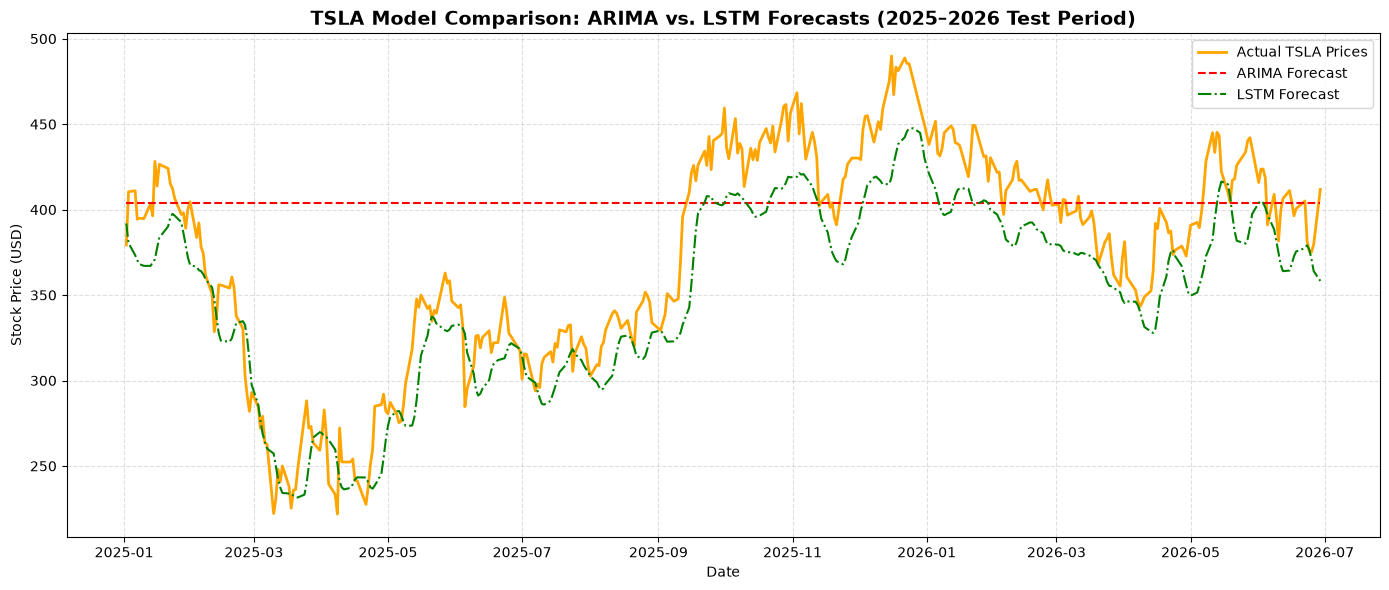

In [12]:
plt.figure(figsize=(14, 6))

# Plot actual market trajectory
plt.plot(test_data.index, actual_prices, label='Actual TSLA Prices', color='orange', linewidth=2)

# Plot model predictions
plt.plot(test_predictions.index, test_predictions, label='ARIMA Forecast', color='red', linestyle='--')
plt.plot(lstm_predictions_series.index, lstm_predictions_series, label='LSTM Forecast', color='green', linestyle='-.')

plt.title("TSLA Model Comparison: ARIMA vs. LSTM Forecasts (2025–2026 Test Period)", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Stock Price (USD)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()